# Database Design

## Database
* It is a structured system is used to store,manage and retrive data
* it is usually controlled by database management system
### real time example
* the college stores the information of students about
* student name
* department
* attendence
* marks
### example


  * Query
   * create database college_db
  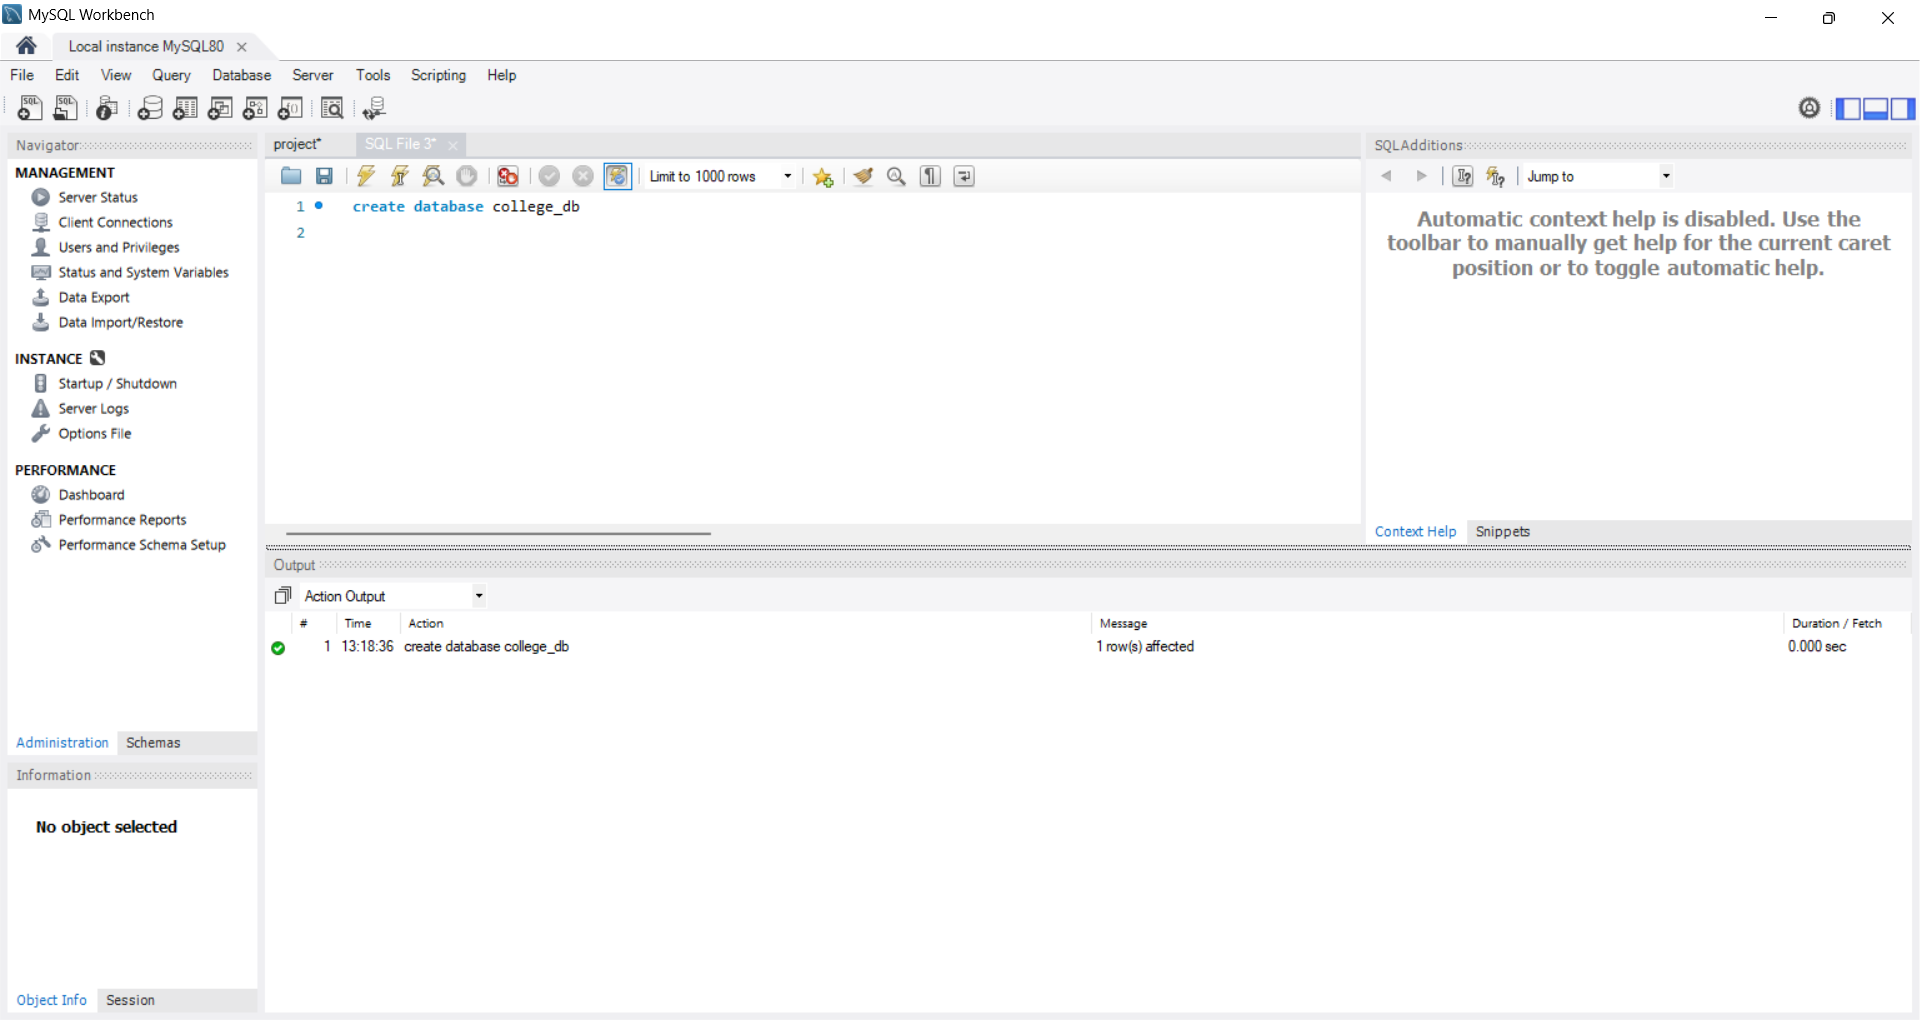

## Tables
* stores data in rows and columns
* column-type of information
* row-one complete record
### real time example
* student attendence register
* sl.no   |   name      |attendence
* 1.      |Ashok        |78
* 2.      |Sai          |82
 
### example
CREATE TABLE students (
    student_id INT,
    student_name VARCHAR(50),
    marks INT
);


|id | name | marks|
| :--- | :---: | :---: |
|1. |sai   |87|
|2. |john  |90|
|3. |gopi  |92|




## Primary Key
* It is a column that uniquely identifies every row in a table.
* two students does'nt have the same id's
### real time example
* A college gives unique if for every student

### example
* CREATE TABLE student(
    student_id INT PRIMARY KEY,
    student_name VARCHAR(50),
    marks INT
);


|id | name | marks|
| :--- | :---: | :---: |
|1. |sai   |87|
|2. |john  |90|
|3. |gopi  |92|

* makes id as unique and prevent null values

## Foreign Key
* It connects one table to another table
* It creates a relation ship between columns from one to primary key of another table
### real time example
* Student ID in the Exam Marks table refers to Student ID in the Students table.
* students table contains student id and student name
* exam marks table contains student id and exam marks
### example

CREATE TABLE customers (
    customer_id INT PRIMARY KEY,
    name VARCHAR(50)
);

CREATE TABLE orders (
    order_id INT PRIMARY KEY,
    order_date DATE,
    customer_id INT,
    FOREIGN KEY (customer_id) REFERENCES customers(customer_id)
);


#### customer table
|customer_id | name | 
| :--- | :---: |
|1. |sai   |
|2. |john  |


#### order table
|order_id | order_date | customer_id|
| :--- | :---: | :---: |
|101|01/09/2005|1|
|102|02/09/2006|2|

## Relationships
* IT describes how tables are connected to each other
* like one to one
* one to many
* many to many
### real time examples
* a departments has many number of students   indicates one to many relationship
* a person can have only one unique identification number    indicates one to one relationship
* one song can belong to many playlists and one playlist can contain many songs.
### example
CREATE TABLE departments (
    dept_id INT PRIMARY KEY,
    dept_name VARCHAR(50)
);

CREATE TABLE students (
    student_id INT PRIMARY KEY,
    student_name VARCHAR(50),
    dept_id INT,
    FOREIGN KEY (dept_id) REFERENCES departments(dept_id)
);

* one department many number of students so it is a one to many relation ship
* departments_table
|dept_id | dept_name | 
| :--- | :---: |
|1. |cse   |
|2. |cse |
|3. |ece  |


## Constraints
* rules applied to columns or tables to restrict the type of data that can be stored.
* They act as schema-level guardrails to ensure data accuracy, reliability, and integrity before any information is written to the database.
* Common constraints used in SQL:
* PRIMARY KEY - uniquely identifies every row in a table
* FOREIGN KEY - links from one table to other table
* NOT NULL - it should not be a blank or null value
* UNIQUE - no duplicate values allowed
* DEFAULT - automatically insert fallback value into a table
### real time example
* college registration
* every student should have unique student_id
* email must be unique
* hostel room is not allocated then default room is warden' room
* unique id should not be blank or null
### example
```sql
CREATE TABLE students (
    student_id INT PRIMARY KEY,
    student_name VARCHAR(50) NOT NULL,
    email VARCHAR(100) UNIQUE,
    marks INT CHECK (marks >= 0 AND marks <= 100),
    status VARCHAR(20) DEFAULT 'Active'
);
insert into students values(11,"ashok","ashok@gmail.com",93,"non active");
select * from students
```

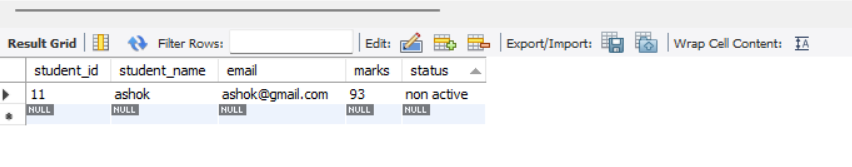

# Queries
## SELECT
* It is used to retrive the data from the table

### real time example
* if a teacher needs to check the attendence she use the select method

### example
```sql
select * from student```


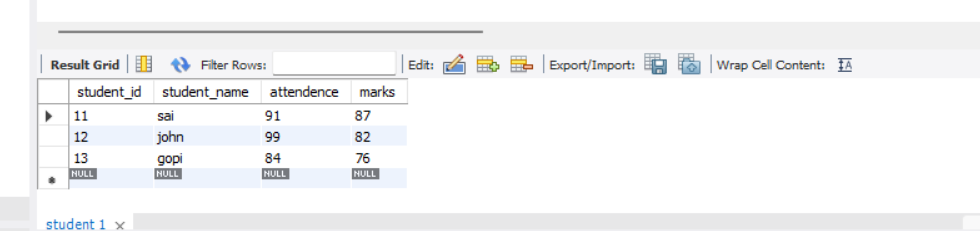

## WHERE
* It is used to filter records based on condition
### real time example
* i want go get the students record whose marks is >80

```sql
select * from student where marks>80
```

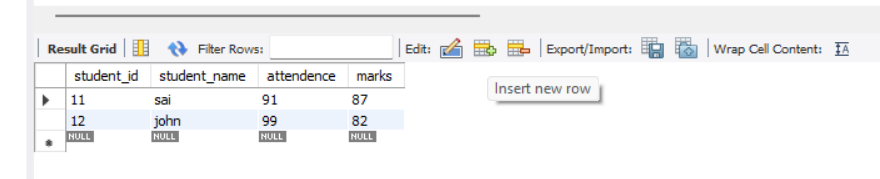

## ORDERBY
* it is used to sort the result based on ascending or descending order

### real time example
* arranging students from highest to lowest
### example
``` sql
select * from student ORDER BY marks="DESC"

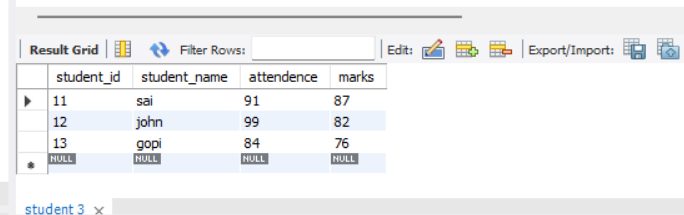

## GROUP BY
* combines rows having the same value into groups.
* some of the functions are
* COUNT()
* SUM()
* AVG()
* MAX()
* MIN()

### real time example
* finding average of the student marks

```sql
SELECT AVG(marks) AS average_marks
FROM student;
```
### example

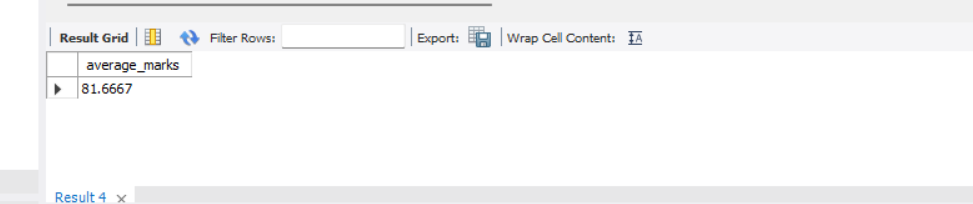

## HAVING
* filters groups created by GROUP BY.
### real time example
* finding students who are having more than 90 attendence
``` sql
SELECT student_name, AVG(marks) AS average_marks
FROM students
GROUP BY student_name
HAVING AVG(marks) > 80;
```
### example

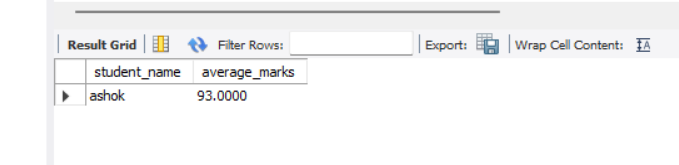

## DISTINCT
* removes duplicates from the table

### real time example
* so many students belongs to several departments

``` sql
SELECT DISTINCT attendence 
FROM student;
```
### example

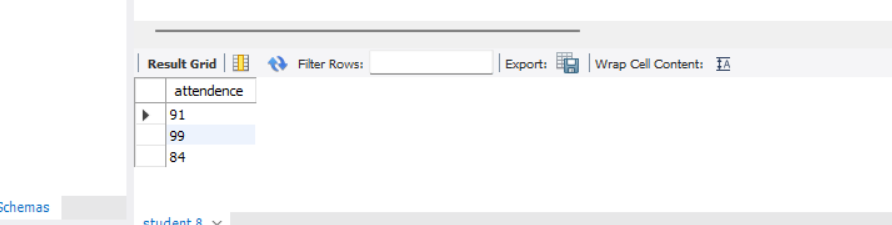

## LIMIT
* restricts the number of rows returned

### real time example
* printing the first 2 elements from the table

``` sql
SELECT * FROM student
LIMIT 2;
```
### example

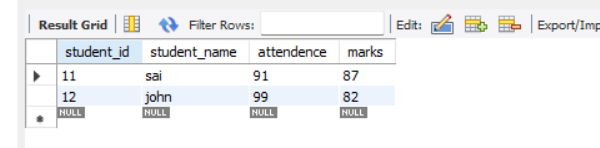

# JOINS
* it is used to print the information from multiple tables
## INNER JOIN
* Returns records that have matching values in both tables.

### real time example
* printing the students along with their departments
``` sql
SELECT s.student_name, d.dept_name
FROM studentss s
INNER JOIN department d
ON s.dept_id = d.dept_id;
```
### example

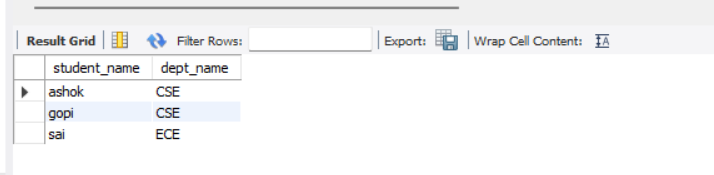

# LEFT JOIN
* returns all records from the left table, even if there is no matching record in the right table.

### real time example
* Show all students, including students who are not assigned to a department.

``` sql
SELECT s.student_name, d.dept_name
FROM studentss s
LEFT JOIN department d
ON s.dept_id = d.dept_id;
```
### example

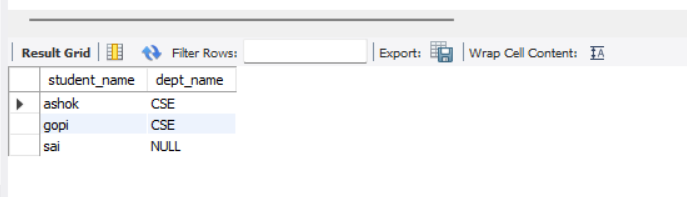

# RIGHT JOIN
* returns all records from the right table, even if there is no matching record in the left table.

### real time example
* Show every department, including departments that currently have no students.

```sql
SELECT s.student_name, d.dept_name
FROM studentss s
RIGHT JOIN department d
ON s.dept_id = d.dept_id;
```
### example

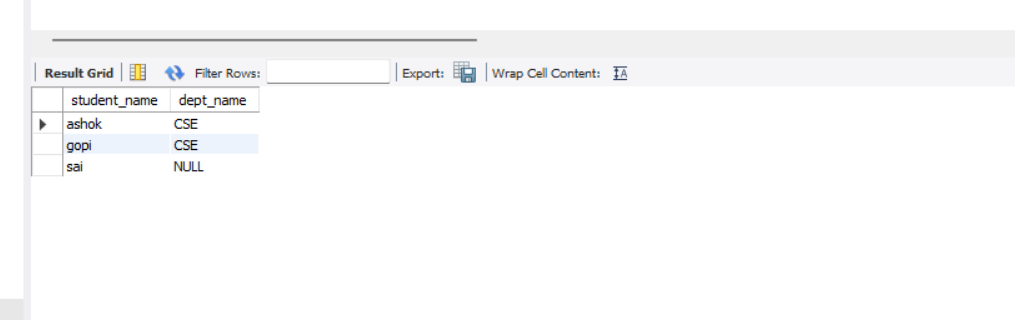

# FULL JOIN

* returns all records from both tables when there is a match in either  left or right table
* it combines the result of both the tables
### real time example
* i want to get all the students and all the departments when there is no match

```sql
SELECT s.student_name, d.dept_name
FROM studentss s
LEFT JOIN department d ON s.dept_id = d.dept_id
UNION
SELECT s.student_name, d.dept_name
FROM studentss s
RIGHT JOIN department d ON s.dept_id = d.dept_id;
```
### example

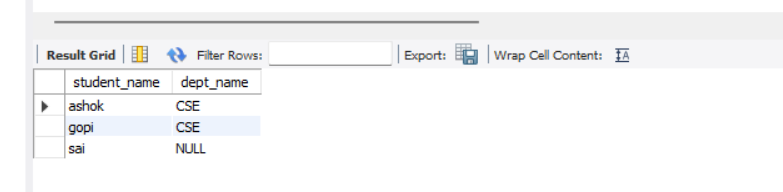

# CROSS JOIN
* it pairs every single row from the first table with every single row from the second table.
*  Unlike INNER JOIN or LEFT JOIN, a CROSS JOIN does not require a join condition
### real time example
* we have 3 students and 4 departments
* each student is combined with every department
``` sql
SELECT s.student_name, d.dept_name
FROM studentss s
CROSS JOIN department d;
```
### example
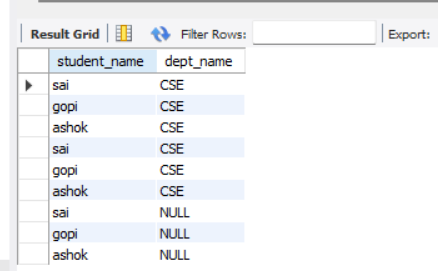

# Advanced SQL
## UNION
* used to combine the result sets of two or more SELECT statements into a single, unified result set.
### Real time example
*  a company has two tables containing employee names from two different branches.
* UNION can combine the employee names from both branches into one result.
```sql
SELECT student_name
FROM studentss
WHERE dept_id = 101
UNION
SELECT student_name
FROM studentss
WHERE dept_id = 103;
```
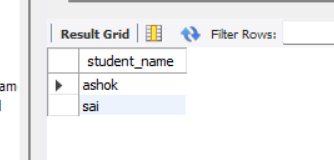

# CASE
* used to add conditional logic to your queries, operating exactly like an if-then-else statement.
* It evaluates conditions sequentially and returns a value as soon as the first condition is met.
### real time example
* printing the student marks above 80

``` sql
SELECT student_name,
       marks,
       CASE
           WHEN marks >= 90 THEN 'Excellent'
           WHEN marks >= 75 THEN 'Good'
           ELSE 'Needs Improvement'
       END AS performance
FROM student;
```
### example
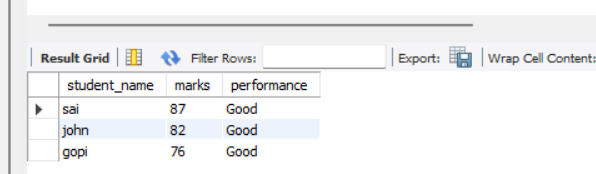

# Subqueries
* A subquery is a query written inside another query.
* The inner query produces a result that the outer query uses.
### real time example
* finding students who scored higher than the average marks.

```sql
SELECT student_name, marks
FROM student
WHERE marks > (
    SELECT AVG(marks)
    FROM student
);
```
* inner query finds the average of the students 
* outer query finds the students who have greater than avg marks


### example
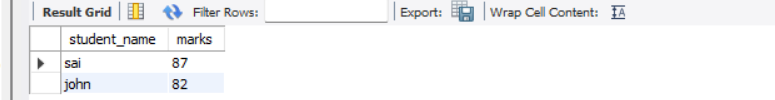

# CTE
* CTE stands for Common Table Expression
* It makes complier queries make easy
### real time example
* Think of preparing a report.
* First, you create a temporary list of students who scored above 80.
* with the list of temporary list we can create another operation
```sql
WITH high_scorers AS (
    SELECT student_id, student_name, marks
    FROM students
    WHERE marks >= 80
)
SELECT *
FROM high_scorers;
```
### example
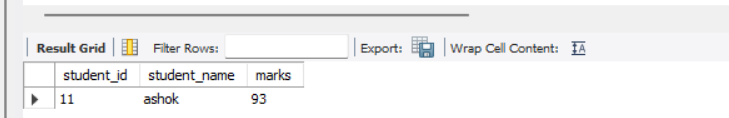

# Views
* A view is a saved SQL query that behaves like a virtual table.
* It does not normally store a separate copy of the underlying data.
### real time example
* if a teacher needs only students name and marks
* instead of writing a query for every time we can create a view
``` sql
CREATE VIEW student_marks AS
SELECT student_name, marks
FROM student;
select * from student_marks
```
* the view saves the query and allow us to use like a table

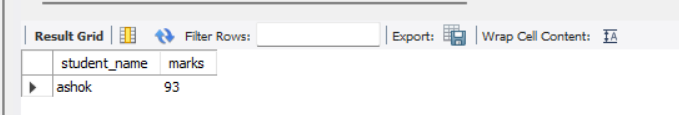

# Indexes
* An index helps the database find data more efficiently, especially when searching frequently on particular columns.
* it is similar to an index in a textbook
### real time example
* Imagine a 500-page book
* Instead of reading every page to find "Python", you check the index and quickly locate the relevant pages.
* A database index works with a similar idea
```sql
CREATE INDEX idx_student_name
ON student(student_name);
select * from student
```
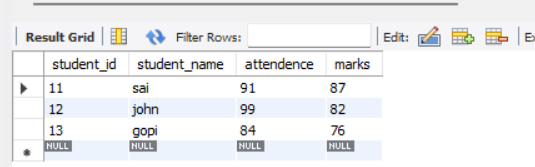

# Window functions
* A window function performs calculations across related rows while still keeping the individual rows visible.
* This is different from GROUP BY.
* GROUP BY--combines rows into groups
* Window Function--calculates across rows but keeps each row
## Row Number()
* it gives a unique sequential number to the each row
### real time example
* finding students from highest to lowest by seqential order
* 1-highest
* 2- second highest
* 3- lowest
``` sql
SELECT student_name,
       marks,
       ROW_NUMBER() OVER (ORDER BY marks DESC) AS row_num
FROM student;
```
### example
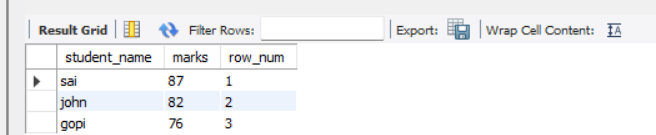

## Rank() function
* assigns the same rank to equal values, but it leaves gaps after a tie.
### real time example
* suppose the student marks are 90,92,92,93
* 90-1,92-2,92-2,93-4
```sql
SELECT student_name,
       marks,
       RANK() OVER (ORDER BY marks DESC) AS student_rank
FROM student;
```
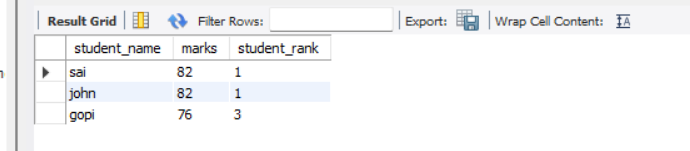

## Dense_Rank()
* same as a rank function does not leaves a gap after a tie

### real time example
* suppose the student marks are 90,92,92,93
* 90-1,92-2,92-2,93-3
```sql
SELECT student_name,
       marks,
       DENSE_RANK() OVER (ORDER BY marks DESC) AS student_rank
FROM students;
```
### example
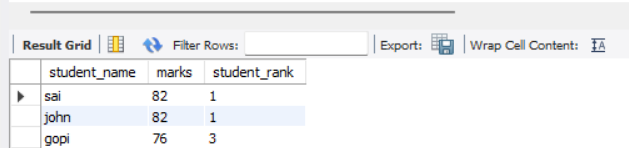

## LAG()
* allows us to access a value from a previous row.

### real time example
* Imagine checking student marks from one exam to the next
* previous exam --- current exam
```sql
SELECT 
    student_id,student_name,attendence,marks,
    LAG(marks, 1, 0) OVER (ORDER BY student_id) AS previous_student_marks
FROM student;
```
### example
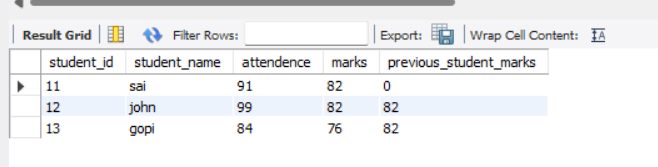


## LEAD()
* allows us to access a value from the next row.

### real time example
* a company wants to check the current  onths sales to the following month sales

``` sql
SELECT 
    student_id,student_name,attendence,marks,
    LEAD(marks, 1, 0) OVER (ORDER BY student_id) AS previous_student_marks
FROM student;
```
### example
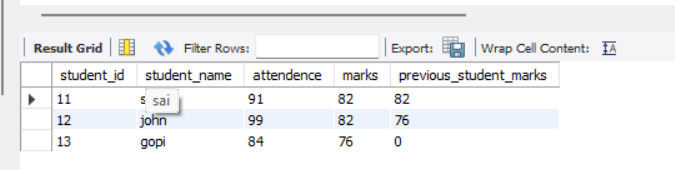